In [ ]:
%pip install torch numpy matplotlib

In [ ]:
# Upgrade the sympy library to resolve the AttributeError
!pip install --upgrade sympy

In [ ]:
import math, random, calendar
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

SEED = 490
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATA_DIR = Path(r"/content")
DATA_PATH = DATA_DIR / "data.txt"
EXAMPLE_INPUT_PATH = DATA_DIR / "example_input.txt"
MODEL_DIR = DATA_DIR / "model"
WEIGHTS_DIR = MODEL_DIR / "weights"
PREDICTIONS_DIR = DATA_DIR / "predictions"
FIGURES_DIR = DATA_DIR / "figures"
for directory in [MODEL_DIR, WEIGHTS_DIR, PREDICTIONS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
assert DATA_PATH.exists(), f"Missing {DATA_PATH}"

Device: cuda


## Parsing, Validation, and Datasets

In [ ]:
DAYS = ["MON", "TUE", "WED", "THU", "FRI", "SAT", "SUN"]
MONTHS = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
LEAPS = ["False", "True"]
DECADES = [str(d) for d in range(180, 221)]
MONTH_TO_IDX = {m: i + 1 for i, m in enumerate(MONTHS)}
MONTH_NUM_TO_TOKEN = {i + 1: m for i, m in enumerate(MONTHS)}
MIN_YEAR, MAX_YEAR = 1800, 2200

def is_leap_year(year: int) -> bool:
    return calendar.isleap(year)

def weekday_token(day: int, month: int, year: int) -> str:
    return DAYS[calendar.weekday(year, month, day)]

def parse_condition_tokens(line: str) -> Tuple[str, str, str, str]:
    return tuple(part.strip("[]") for part in line.strip().split()[:4])

def parse_data_line(line: str) -> Tuple[Tuple[str, str, str, str], str]:
    parts = line.strip().split()
    return tuple(part.strip("[]") for part in parts[:4]), parts[4]

def parse_date(date_str: str) -> Tuple[int, int, int]:
    d, m, y = date_str.split("-")
    return int(d), int(m), int(y)

def format_condition(cond: Tuple[str, str, str, str]) -> str:
    day, month, leap, decade = cond
    return f"[{day}] [{month}] [{leap}] [{decade}]"

def date_satisfies(cond: Tuple[str, str, str, str], date_str: str) -> bool:
    try:
        day_tok, month_tok, leap_tok, decade_tok = cond
        d, m, y = parse_date(date_str)
        if not (MIN_YEAR <= y <= MAX_YEAR and 1 <= m <= 12):
            return False
        if not (1 <= d <= calendar.monthrange(y, m)[1]):
            return False
        return (
            weekday_token(d, m, y) == day_tok and
            MONTH_NUM_TO_TOKEN[m] == month_tok and
            str(is_leap_year(y)) == leap_tok and
            str(y // 10) == decade_tok
        )
    except Exception:
        return False

def all_valid_dates_for_condition(cond: Tuple[str, str, str, str]) -> List[str]:
    day_tok, month_tok, leap_tok, decade_tok = cond
    month = MONTH_TO_IDX[month_tok]
    start_year = int(decade_tok) * 10
    out = []
    for year in range(start_year, start_year + 10):
        if year < MIN_YEAR or year > MAX_YEAR or str(is_leap_year(year)) != leap_tok:
            continue
        for day in range(1, calendar.monthrange(year, month)[1] + 1):
            if weekday_token(day, month, year) == day_tok:
                out.append(f"{day}-{month}-{year}")
    return out

def deterministic_valid_date(cond: Tuple[str, str, str, str]) -> str:
    valid = all_valid_dates_for_condition(cond)
    if not valid:
        raise ValueError(f"No valid date exists for {cond}")
    return valid[0]

raw_lines = [line.strip() for line in DATA_PATH.read_text().splitlines() if line.strip()]
examples = [parse_data_line(line) for line in raw_lines]
print("Examples:", len(examples), examples[0])
print("Validation sanity check:", date_satisfies(*examples[0]))

Examples: 146462 (('WED', 'JAN', 'False', '180'), '1-1-1800')
Validation sanity check: True


In [ ]:
N_DAY, N_MONTH = 31, 12
N_YEAR = MAX_YEAR - MIN_YEAR + 1
COND_DIM = len(DAYS) + len(MONTHS) + len(LEAPS) + len(DECADES)
DATE_DIM = N_DAY + N_MONTH + N_YEAR

def condition_to_onehot(cond: Tuple[str, str, str, str]) -> torch.Tensor:
    day, month, leap, decade = cond
    x = torch.zeros(COND_DIM, dtype=torch.float32)
    offset = 0
    x[offset + DAYS.index(day)] = 1; offset += len(DAYS)
    x[offset + MONTHS.index(month)] = 1; offset += len(MONTHS)
    x[offset + LEAPS.index(leap)] = 1; offset += len(LEAPS)
    x[offset + DECADES.index(decade)] = 1
    return x

def date_to_indices(date_str: str) -> Tuple[int, int, int]:
    d, m, y = parse_date(date_str)
    return d - 1, m - 1, y - MIN_YEAR

def date_indices_to_string(day_idx: int, month_idx: int, year_idx: int) -> str:
    d, m, y = int(day_idx) + 1, int(month_idx) + 1, int(year_idx) + MIN_YEAR
    if not (MIN_YEAR <= y <= MAX_YEAR and 1 <= m <= 12):
        return "1-1-1800"
    d = max(1, min(d, calendar.monthrange(y, m)[1]))
    return f"{d}-{m}-{y}"

def date_to_onehot(date_str: str) -> torch.Tensor:
    di, mi, yi = date_to_indices(date_str)
    y = torch.zeros(DATE_DIM, dtype=torch.float32)
    y[di] = 1
    y[N_DAY + mi] = 1
    y[N_DAY + N_MONTH + yi] = 1
    return y

class DateConditionDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples
    def __len__(self):
        return len(self.examples)
    def __getitem__(self, idx):
        cond, date = self.examples[idx]
        di, mi, yi = date_to_indices(date)
        return {
            "cond_tuple": cond,
            "date_str": date,
            "cond_vec": condition_to_onehot(cond),
            "date_onehot": date_to_onehot(date),
            "day_idx": torch.tensor(di, dtype=torch.long),
            "month_idx": torch.tensor(mi, dtype=torch.long),
            "year_idx": torch.tensor(yi, dtype=torch.long),
        }

dataset = DateConditionDataset(examples)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))
BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
print("Train/val:", len(train_ds), len(val_ds))

Train/val: 131815 14647


In [ ]:
def normalize_collated_conditions(cond_tuple_field):
    # Default PyTorch collation turns a batch of 4-tuples into 4 tuples.
    if len(cond_tuple_field) == 4 and isinstance(cond_tuple_field[0], tuple):
        return [tuple(x) for x in zip(*cond_tuple_field)]
    return [tuple(x) for x in cond_tuple_field]

def evaluate_condition_pass_rate(predict_fn, data_loader, max_batches: Optional[int] = None) -> float:
    total = passed = 0
    for i, batch in enumerate(data_loader):
        if max_batches is not None and i >= max_batches:
            break
        conds = normalize_collated_conditions(batch["cond_tuple"])
        preds = predict_fn(conds)
        for cond, pred in zip(conds, preds):
            total += 1
            passed += int(date_satisfies(cond, pred))
    return passed / max(total, 1)

def repair_invalid_predictions(conds: List[Tuple[str, str, str, str]], preds: List[str]) -> List[str]:
    return [pred if date_satisfies(tuple(cond), pred) else deterministic_valid_date(tuple(cond))
            for cond, pred in zip(conds, preds)]

def write_predictions(input_path: Path, output_path: Path, predict_fn, repair: bool = True) -> None:
    lines = [line.strip() for line in input_path.read_text().splitlines() if line.strip()]
    conds = [parse_condition_tokens(line) for line in lines]
    preds = predict_fn(conds)
    if repair:
        preds = repair_invalid_predictions(conds, preds)
    output_lines = [f"{format_condition(cond)} {pred}" for cond, pred in zip(conds, preds)]
    output_path.write_text("\n".join(output_lines) + "\n")
    print(f"Wrote {len(output_lines)} predictions to {output_path}")

## Model 1 - Conditional GAN


In [ ]:
class ConditionalGenerator(nn.Module):
    def __init__(self, cond_dim: int, noise_dim: int = 64, hidden_dim: int = 256):
        super().__init__()
        self.noise_dim = noise_dim
        self.net = nn.Sequential(
            nn.Linear(cond_dim + noise_dim, hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, DATE_DIM),
        )
    def logits(self, cond_vec: torch.Tensor) -> torch.Tensor:
        z = torch.randn(cond_vec.size(0), self.noise_dim, device=cond_vec.device)
        return self.net(torch.cat([cond_vec, z], dim=1))
    def forward(self, cond_vec: torch.Tensor, tau: float = 0.8, hard: bool = True) -> torch.Tensor:
        logits = self.logits(cond_vec)
        day = F.gumbel_softmax(logits[:, :N_DAY], tau=tau, hard=hard)
        month = F.gumbel_softmax(logits[:, N_DAY:N_DAY + N_MONTH], tau=tau, hard=hard)
        year = F.gumbel_softmax(logits[:, N_DAY + N_MONTH:], tau=tau, hard=hard)
        return torch.cat([day, month, year], dim=1)

class ConditionalDiscriminator(nn.Module):
    def __init__(self, cond_dim: int, date_dim: int, hidden_dim: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim + date_dim, hidden_dim), nn.LeakyReLU(0.2), nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(0.2), nn.Dropout(0.2),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, cond_vec: torch.Tensor, date_vec: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([cond_vec, date_vec], dim=1)).squeeze(1)

def split_date_logits(logits: torch.Tensor):
    return logits[:, :N_DAY], logits[:, N_DAY:N_DAY + N_MONTH], logits[:, N_DAY + N_MONTH:]

def categorical_date_loss(logits: torch.Tensor, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
    day_logits, month_logits, year_logits = split_date_logits(logits)
    return (
        F.cross_entropy(day_logits, batch["day_idx"].to(DEVICE)) +
        F.cross_entropy(month_logits, batch["month_idx"].to(DEVICE)) +
        F.cross_entropy(year_logits, batch["year_idx"].to(DEVICE))
    )

def train_gan(generator, discriminator, loader, epochs: int = 5, lr: float = 2e-4, lambda_supervised: float = 0.5):
    generator.to(DEVICE); discriminator.to(DEVICE)
    g_opt = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    d_opt = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()
    history = {"g_loss": [], "d_loss": []}
    for epoch in range(1, epochs + 1):
        g_losses, d_losses = [], []
        for batch in loader:
            cond_vec, real_date = batch["cond_vec"].to(DEVICE), batch["date_onehot"].to(DEVICE)
            bs = cond_vec.size(0)
            fake_date = generator(cond_vec).detach()
            d_loss = bce(discriminator(cond_vec, real_date), torch.ones(bs, device=DEVICE))
            d_loss += bce(discriminator(cond_vec, fake_date), torch.zeros(bs, device=DEVICE))
            d_opt.zero_grad(); d_loss.backward(); d_opt.step()

            fake_date = generator(cond_vec)
            adv_loss = bce(discriminator(cond_vec, fake_date), torch.ones(bs, device=DEVICE))
            sup_loss = categorical_date_loss(generator.logits(cond_vec), batch)
            g_loss = adv_loss + lambda_supervised * sup_loss
            g_opt.zero_grad(); g_loss.backward(); g_opt.step()
            g_losses.append(g_loss.item()); d_losses.append(d_loss.item())
        history["g_loss"].append(float(np.mean(g_losses)))
        history["d_loss"].append(float(np.mean(d_losses)))
        print(f"GAN epoch {epoch:02d}: G={history['g_loss'][-1]:.4f}, D={history['d_loss'][-1]:.4f}")
    return history

@torch.no_grad()
def gan_predict(generator, conds: List[Tuple[str, str, str, str]], attempts: int = 10) -> List[str]:
    generator.eval().to(DEVICE)
    outputs = []
    for cond in conds:
        cond_vec = condition_to_onehot(tuple(cond)).unsqueeze(0).to(DEVICE)
        best = None
        for _ in range(attempts):
            day_logits, month_logits, year_logits = split_date_logits(generator.logits(cond_vec))
            pred = date_indices_to_string(day_logits.argmax(1).item(), month_logits.argmax(1).item(), year_logits.argmax(1).item())
            best = pred
            if date_satisfies(tuple(cond), pred):
                break
        outputs.append(best)
    return outputs

## Models 2 and 3 - Seq2Seq RNN and Transformer


In [ ]:
SPECIALS = ["<pad>", "<sos>", "<eos>"]
INPUT_TOKENS = SPECIALS + DAYS + MONTHS + LEAPS + DECADES
OUTPUT_CHARS = SPECIALS + sorted(set("0123456789-"))
IN_STOI = {t: i for i, t in enumerate(INPUT_TOKENS)}
OUT_STOI = {t: i for i, t in enumerate(OUTPUT_CHARS)}
OUT_ITOS = {i: t for t, i in OUT_STOI.items()}
PAD_IN, PAD_OUT, SOS_OUT, EOS_OUT = IN_STOI["<pad>"], OUT_STOI["<pad>"], OUT_STOI["<sos>"], OUT_STOI["<eos>"]
MAX_OUT_LEN = len("31-12-2200") + 2

class SequenceDateDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples
    def __len__(self):
        return len(self.examples)
    def __getitem__(self, idx):
        cond, date = self.examples[idx]
        src = torch.tensor([IN_STOI[t] for t in cond], dtype=torch.long)
        tgt = torch.tensor([SOS_OUT] + [OUT_STOI[ch] for ch in date] + [EOS_OUT], dtype=torch.long)
        return {"cond_tuple": cond, "date_str": date, "src": src, "tgt": tgt}

def seq_collate(batch):
    return {
        "cond_tuple": [b["cond_tuple"] for b in batch],
        "date_str": [b["date_str"] for b in batch],
        "src": torch.stack([b["src"] for b in batch]),
        "tgt": nn.utils.rnn.pad_sequence([b["tgt"] for b in batch], batch_first=True, padding_value=PAD_OUT),
    }

seq_dataset = SequenceDateDataset(examples)
seq_train_ds, seq_val_ds = random_split(seq_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))
seq_train_loader = DataLoader(seq_train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=seq_collate)
seq_val_loader = DataLoader(seq_val_ds, batch_size=BATCH_SIZE, collate_fn=seq_collate)

def decode_output_tokens(tokens: List[int]) -> str:
    chars = []
    for tok in tokens:
        if tok in (SOS_OUT, PAD_OUT):
            continue
        if tok == EOS_OUT:
            break
        chars.append(OUT_ITOS[int(tok)])
    return "".join(chars)

class Seq2SeqRNN(nn.Module):
    def __init__(self, input_vocab: int, output_vocab: int, emb_dim: int = 64, hidden_dim: int = 192, rnn_type: str = "lstm"):
        super().__init__()
        rnn_cls = nn.LSTM if rnn_type.lower() == "lstm" else nn.GRU
        self.src_emb = nn.Embedding(input_vocab, emb_dim, padding_idx=PAD_IN)
        self.tgt_emb = nn.Embedding(output_vocab, emb_dim, padding_idx=PAD_OUT)
        self.encoder = rnn_cls(emb_dim, hidden_dim, batch_first=True)
        self.decoder = rnn_cls(emb_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, output_vocab)
    def forward(self, src: torch.Tensor, tgt_in: torch.Tensor) -> torch.Tensor:
        _, state = self.encoder(self.src_emb(src))
        dec_out, _ = self.decoder(self.tgt_emb(tgt_in), state)
        return self.out(dec_out)
    @torch.no_grad()
    def generate(self, src: torch.Tensor, max_len: int = MAX_OUT_LEN) -> torch.Tensor:
        _, state = self.encoder(self.src_emb(src))
        ys = torch.full((src.size(0), 1), SOS_OUT, dtype=torch.long, device=src.device)
        finished = torch.zeros(src.size(0), dtype=torch.bool, device=src.device)
        for _ in range(max_len - 1):
            dec_out, state = self.decoder(self.tgt_emb(ys[:, -1:]), state)
            nxt = self.out(dec_out[:, -1]).argmax(dim=1)
            ys = torch.cat([ys, nxt[:, None]], dim=1)
            finished |= nxt.eq(EOS_OUT)
            if finished.all():
                break
        return ys

def train_seq2seq(model, loader, epochs: int = 5, lr: float = 1e-3):
    model.to(DEVICE); opt = torch.optim.Adam(model.parameters(), lr=lr); history = {"train_loss": []}
    for epoch in range(1, epochs + 1):
        model.train(); losses = []
        for batch in loader:
            src, tgt = batch["src"].to(DEVICE), batch["tgt"].to(DEVICE)
            logits = model(src, tgt[:, :-1])
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1), ignore_index=PAD_OUT)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            losses.append(loss.item())
        history["train_loss"].append(float(np.mean(losses)))
        print(f"Seq2Seq epoch {epoch:02d}: loss={history['train_loss'][-1]:.4f}")
    return history

@torch.no_grad()
def seq2seq_predict(model, conds: List[Tuple[str, str, str, str]]) -> List[str]:
    src = torch.tensor([[IN_STOI[t] for t in tuple(cond)] for cond in conds], dtype=torch.long, device=DEVICE)
    out = model.to(DEVICE).eval().generate(src).cpu().tolist()
    return [decode_output_tokens(row) for row in out]

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 128):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1)]

class DateTransformer(nn.Module):
    def __init__(self, input_vocab: int, output_vocab: int, d_model: int = 128, nhead: int = 4, num_layers: int = 3):
        super().__init__()
        self.d_model = d_model
        self.src_emb = nn.Embedding(input_vocab, d_model, padding_idx=PAD_IN)
        self.tgt_emb = nn.Embedding(output_vocab, d_model, padding_idx=PAD_OUT)
        self.pos = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead, num_encoder_layers=num_layers,
            num_decoder_layers=num_layers, dim_feedforward=256, dropout=0.1, batch_first=True
        )
        self.out = nn.Linear(d_model, output_vocab)
    def forward(self, src: torch.Tensor, tgt_in: torch.Tensor) -> torch.Tensor:
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_in.size(1), device=tgt_in.device)
        src_emb = self.pos(self.src_emb(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos(self.tgt_emb(tgt_in) * math.sqrt(self.d_model))
        return self.out(self.transformer(src_emb, tgt_emb, tgt_mask=tgt_mask))
    @torch.no_grad()
    def generate(self, src: torch.Tensor, max_len: int = MAX_OUT_LEN) -> torch.Tensor:
        ys = torch.full((src.size(0), 1), SOS_OUT, dtype=torch.long, device=src.device)
        finished = torch.zeros(src.size(0), dtype=torch.bool, device=src.device)
        for _ in range(max_len - 1):
            nxt = self.forward(src, ys)[:, -1].argmax(dim=1)
            ys = torch.cat([ys, nxt[:, None]], dim=1)
            finished |= nxt.eq(EOS_OUT)
            if finished.all():
                break
        return ys

def train_transformer(model, loader, epochs: int = 5, lr: float = 3e-4):
    model.to(DEVICE); opt = torch.optim.AdamW(model.parameters(), lr=lr); history = {"train_loss": []}
    for epoch in range(1, epochs + 1):
        model.train(); losses = []
        for batch in loader:
            src, tgt = batch["src"].to(DEVICE), batch["tgt"].to(DEVICE)
            logits = model(src, tgt[:, :-1])
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1), ignore_index=PAD_OUT)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            losses.append(loss.item())
        history["train_loss"].append(float(np.mean(losses)))
        print(f"Transformer epoch {epoch:02d}: loss={history['train_loss'][-1]:.4f}")
    return history

@torch.no_grad()
def transformer_predict(model, conds: List[Tuple[str, str, str, str]]) -> List[str]:
    src = torch.tensor([[IN_STOI[t] for t in tuple(cond)] for cond in conds], dtype=torch.long, device=DEVICE)
    out = model.to(DEVICE).eval().generate(src).cpu().tolist()
    return [decode_output_tokens(row) for row in out]

## Model 4 - Conditional VAE


In [ ]:
class ConditionalVAE(nn.Module):
    def __init__(self, cond_dim: int, date_dim: int, latent_dim: int = 32, hidden_dim: int = 256):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(cond_dim + date_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(cond_dim + latent_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, DATE_DIM),
        )
    def encode(self, cond_vec: torch.Tensor, date_vec: torch.Tensor):
        h = self.encoder(torch.cat([cond_vec, date_vec], dim=1))
        return self.mu(h), self.logvar(h)
    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
    def decode(self, cond_vec: torch.Tensor, z: torch.Tensor):
        return self.decoder(torch.cat([cond_vec, z], dim=1))
    def forward(self, cond_vec: torch.Tensor, date_vec: torch.Tensor):
        mu, logvar = self.encode(cond_vec, date_vec)
        return self.decode(cond_vec, self.reparameterize(mu, logvar)), mu, logvar

def vae_loss(logits, mu, logvar, batch, beta: float = 0.01):
    recon = categorical_date_loss(logits, batch)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon.detach(), kl.detach()

def train_vae(model, loader, epochs: int = 5, lr: float = 1e-3, beta: float = 0.01):
    model.to(DEVICE); opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "recon": [], "kl": []}
    for epoch in range(1, epochs + 1):
        model.train(); losses = []; recons = []; kls = []
        for batch in loader:
            cond_vec, date_vec = batch["cond_vec"].to(DEVICE), batch["date_onehot"].to(DEVICE)
            logits, mu, logvar = model(cond_vec, date_vec)
            loss, recon, kl = vae_loss(logits, mu, logvar, batch, beta)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item()); recons.append(recon.item()); kls.append(kl.item())
        history["loss"].append(float(np.mean(losses)))
        history["recon"].append(float(np.mean(recons)))
        history["kl"].append(float(np.mean(kls)))
        print(f"VAE epoch {epoch:02d}: loss={history['loss'][-1]:.4f}, recon={history['recon'][-1]:.4f}, kl={history['kl'][-1]:.4f}")
    return history

@torch.no_grad()
def vae_predict(model, conds: List[Tuple[str, str, str, str]], attempts: int = 10) -> List[str]:
    model.eval().to(DEVICE)
    outputs = []
    for cond in conds:
        cond_vec = condition_to_onehot(tuple(cond)).unsqueeze(0).to(DEVICE)
        best = None
        for _ in range(attempts):
            z = torch.randn(1, model.latent_dim, device=DEVICE)
            day_logits, month_logits, year_logits = split_date_logits(model.decode(cond_vec, z))
            pred = date_indices_to_string(day_logits.argmax(1).item(), month_logits.argmax(1).item(), year_logits.argmax(1).item())
            best = pred
            if date_satisfies(tuple(cond), pred):
                break
        outputs.append(best)
    return outputs

## Saving, Validation Losses, and Output Analysis



In [ ]:
def save_checkpoint(path: Path, model: nn.Module, extra: Optional[dict] = None) -> None:
    payload = {"state_dict": model.state_dict(), "extra": extra or {}}
    torch.save(payload, path)
    print(f"Saved weights: {path}")

def save_loss_plot(histories: Dict[str, Dict[str, List[float]]], output_path: Path) -> None:
    if not histories:
        print("No histories to plot yet.")
        return
    plt.figure(figsize=(12, 6))
    for name, hist in histories.items():
        for key, values in hist.items():
            if key.endswith("loss") or key in {"loss", "val_loss", "g_loss", "d_loss", "val_supervised_loss"}:
                plt.plot(values, label=f"{name} {key}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation/Test Loss Curves")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()
    print(f"Saved loss graph: {output_path}")

@torch.no_grad()
def generator_validation_loss(generator, loader) -> float:
    generator.eval().to(DEVICE)
    losses = []
    for batch in loader:
        cond_vec = batch["cond_vec"].to(DEVICE)
        losses.append(categorical_date_loss(generator.logits(cond_vec), batch).item())
    return float(np.mean(losses))

@torch.no_grad()
def sequence_validation_loss(model, loader) -> float:
    model.eval().to(DEVICE)
    losses = []
    for batch in loader:
        src, tgt = batch["src"].to(DEVICE), batch["tgt"].to(DEVICE)
        logits = model(src, tgt[:, :-1])
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1), ignore_index=PAD_OUT)
        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def vae_validation_loss(model, loader, beta: float = 0.01) -> float:
    model.eval().to(DEVICE)
    losses = []
    for batch in loader:
        cond_vec, date_vec = batch["cond_vec"].to(DEVICE), batch["date_onehot"].to(DEVICE)
        logits, mu, logvar = model(cond_vec, date_vec)
        loss, _, _ = vae_loss(logits, mu, logvar, batch, beta=beta)
        losses.append(loss.item())
    return float(np.mean(losses))

def collect_conditions(data_loader, limit: Optional[int] = None) -> List[Tuple[str, str, str, str]]:
    conds = []
    for batch in data_loader:
        conds.extend(normalize_collated_conditions(batch["cond_tuple"]))
        if limit is not None and len(conds) >= limit:
            return conds[:limit]
    return conds

def analyze_model_outputs(name: str, predict_fn, data_loader, output_path: Path, sample_count: int = 10) -> Dict[str, float]:
    conds = collect_conditions(data_loader)
    raw_preds = predict_fn(conds)
    repaired_preds = repair_invalid_predictions(conds, raw_preds)
    raw_pass = np.mean([date_satisfies(cond, pred) for cond, pred in zip(conds, raw_preds)])
    repaired_pass = np.mean([date_satisfies(cond, pred) for cond, pred in zip(conds, repaired_preds)])

    output_lines = [f"{format_condition(cond)} {pred}" for cond, pred in zip(conds, repaired_preds)]
    output_path.write_text("\n".join(output_lines) + "\n")

    failed = [(cond, pred, repaired) for cond, pred, repaired in zip(conds, raw_preds, repaired_preds) if not date_satisfies(cond, pred)]
    print(f"\n{name} output analysis")
    print(f"Raw constraint pass rate: {raw_pass:.4f}")
    print(f"Repaired constraint pass rate: {repaired_pass:.4f}")
    print(f"Prediction file: {output_path}")
    print("Sample repaired predictions:")
    for line in output_lines[:sample_count]:
        print("  ", line)
    if failed:
        print("Sample raw failures repaired by validator:")
        for cond, pred, repaired in failed[:min(5, sample_count)]:
            print(f"  {format_condition(cond)} raw={pred!r} repaired={repaired!r}")
    else:
        print("No raw failures found in this evaluation set.")
    return {"raw_pass_rate": float(raw_pass), "repaired_pass_rate": float(repaired_pass), "n": len(conds)}

# Override the earlier training helpers so they track validation/test loss too.
def train_gan(generator, discriminator, loader, val_loader=None, epochs: int = 5, lr: float = 2e-4, lambda_supervised: float = 0.5):
    generator.to(DEVICE); discriminator.to(DEVICE)
    g_opt = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    d_opt = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()
    history = {"g_loss": [], "d_loss": [], "val_supervised_loss": []}
    for epoch in range(1, epochs + 1):
        generator.train(); discriminator.train(); g_losses, d_losses = [], []
        for batch in loader:
            cond_vec, real_date = batch["cond_vec"].to(DEVICE), batch["date_onehot"].to(DEVICE)
            bs = cond_vec.size(0)
            fake_date = generator(cond_vec).detach()
            d_loss = bce(discriminator(cond_vec, real_date), torch.ones(bs, device=DEVICE))
            d_loss += bce(discriminator(cond_vec, fake_date), torch.zeros(bs, device=DEVICE))
            d_opt.zero_grad(); d_loss.backward(); d_opt.step()

            fake_date = generator(cond_vec)
            adv_loss = bce(discriminator(cond_vec, fake_date), torch.ones(bs, device=DEVICE))
            sup_loss = categorical_date_loss(generator.logits(cond_vec), batch)
            g_loss = adv_loss + lambda_supervised * sup_loss
            g_opt.zero_grad(); g_loss.backward(); g_opt.step()
            g_losses.append(g_loss.item()); d_losses.append(d_loss.item())
        history["g_loss"].append(float(np.mean(g_losses)))
        history["d_loss"].append(float(np.mean(d_losses)))
        history["val_supervised_loss"].append(generator_validation_loss(generator, val_loader or loader))
        print(f"GAN epoch {epoch:02d}: G={history['g_loss'][-1]:.4f}, D={history['d_loss'][-1]:.4f}, val={history['val_supervised_loss'][-1]:.4f}")
    return history

def train_seq2seq(model, loader, val_loader=None, epochs: int = 5, lr: float = 1e-3):
    model.to(DEVICE); opt = torch.optim.Adam(model.parameters(), lr=lr); history = {"train_loss": [], "val_loss": []}
    for epoch in range(1, epochs + 1):
        model.train(); losses = []
        for batch in loader:
            src, tgt = batch["src"].to(DEVICE), batch["tgt"].to(DEVICE)
            logits = model(src, tgt[:, :-1])
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1), ignore_index=PAD_OUT)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            losses.append(loss.item())
        history["train_loss"].append(float(np.mean(losses)))
        history["val_loss"].append(sequence_validation_loss(model, val_loader or loader))
        print(f"Seq2Seq epoch {epoch:02d}: train={history['train_loss'][-1]:.4f}, val={history['val_loss'][-1]:.4f}")
    return history

def train_transformer(model, loader, val_loader=None, epochs: int = 5, lr: float = 3e-4):
    model.to(DEVICE); opt = torch.optim.AdamW(model.parameters(), lr=lr); history = {"train_loss": [], "val_loss": []}
    for epoch in range(1, epochs + 1):
        model.train(); losses = []
        for batch in loader:
            src, tgt = batch["src"].to(DEVICE), batch["tgt"].to(DEVICE)
            logits = model(src, tgt[:, :-1])
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1), ignore_index=PAD_OUT)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            losses.append(loss.item())
        history["train_loss"].append(float(np.mean(losses)))
        history["val_loss"].append(sequence_validation_loss(model, val_loader or loader))
        print(f"Transformer epoch {epoch:02d}: train={history['train_loss'][-1]:.4f}, val={history['val_loss'][-1]:.4f}")
    return history

def train_vae(model, loader, val_loader=None, epochs: int = 5, lr: float = 1e-3, beta: float = 0.01):
    model.to(DEVICE); opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "recon": [], "kl": [], "val_loss": []}
    for epoch in range(1, epochs + 1):
        model.train(); losses = []; recons = []; kls = []
        for batch in loader:
            cond_vec, date_vec = batch["cond_vec"].to(DEVICE), batch["date_onehot"].to(DEVICE)
            logits, mu, logvar = model(cond_vec, date_vec)
            loss, recon, kl = vae_loss(logits, mu, logvar, batch, beta)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item()); recons.append(recon.item()); kls.append(kl.item())
        history["loss"].append(float(np.mean(losses)))
        history["recon"].append(float(np.mean(recons)))
        history["kl"].append(float(np.mean(kls)))
        history["val_loss"].append(vae_validation_loss(model, val_loader or loader, beta=beta))
        print(f"VAE epoch {epoch:02d}: train={history['loss'][-1]:.4f}, val={history['val_loss'][-1]:.4f}, kl={history['kl'][-1]:.4f}")
    return history

## Training and Evaluation



In [ ]:
# %pip install -U --force-reinstall sympy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 29.8 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/

In [ ]:
RUN_TRAINING = True
EPOCHS = 5
trained_models, histories = {}, {}

if RUN_TRAINING:
    gan_G = ConditionalGenerator(COND_DIM)
    gan_D = ConditionalDiscriminator(COND_DIM, DATE_DIM)
    histories["GAN"] = train_gan(gan_G, gan_D, train_loader, val_loader=val_loader, epochs=EPOCHS)
    save_checkpoint(WEIGHTS_DIR / "gan_generator.pt", gan_G, {"model": "ConditionalGenerator", "history": histories["GAN"]})
    save_checkpoint(WEIGHTS_DIR / "gan_discriminator.pt", gan_D, {"model": "ConditionalDiscriminator", "history": histories["GAN"]})
    trained_models["GAN"] = gan_G

    seq_model = Seq2SeqRNN(len(INPUT_TOKENS), len(OUTPUT_CHARS), rnn_type="lstm")
    histories["Seq2Seq LSTM"] = train_seq2seq(seq_model, seq_train_loader, val_loader=seq_val_loader, epochs=EPOCHS)
    save_checkpoint(WEIGHTS_DIR / "seq2seq_lstm.pt", seq_model, {"model": "Seq2SeqRNN", "history": histories["Seq2Seq LSTM"]})
    trained_models["Seq2Seq LSTM"] = seq_model

    tr_model = DateTransformer(len(INPUT_TOKENS), len(OUTPUT_CHARS))
    histories["Transformer"] = train_transformer(tr_model, seq_train_loader, val_loader=seq_val_loader, epochs=EPOCHS)
    save_checkpoint(WEIGHTS_DIR / "transformer.pt", tr_model, {"model": "DateTransformer", "history": histories["Transformer"]})
    trained_models["Transformer"] = tr_model

    vae_model = ConditionalVAE(COND_DIM, DATE_DIM)
    histories["VAE"] = train_vae(vae_model, train_loader, val_loader=val_loader, epochs=EPOCHS)
    save_checkpoint(WEIGHTS_DIR / "vae.pt", vae_model, {"model": "ConditionalVAE", "history": histories["VAE"]})
    trained_models["VAE"] = vae_model
else:
    print("Training is disabled. Change RUN_TRAINING to True when ready.")

GAN epoch 01: G=6.5617, D=0.8892, val=9.0204
GAN epoch 02: G=8.5245, D=0.2303, val=7.9979
GAN epoch 03: G=7.0843, D=0.7557, val=5.6820
GAN epoch 04: G=3.8959, D=1.3090, val=5.3531
GAN epoch 05: G=3.4696, D=1.3630, val=5.3095
Saved weights: /content/model/weights/gan_generator.pt
Saved weights: /content/model/weights/gan_discriminator.pt
Seq2Seq epoch 01: train=0.8248, val=0.5373
Seq2Seq epoch 02: train=0.5306, val=0.5259
Seq2Seq epoch 03: train=0.5251, val=0.5246
Seq2Seq epoch 04: train=0.5234, val=0.5232
Seq2Seq epoch 05: train=0.5226, val=0.5225
Saved weights: /content/model/weights/seq2seq_lstm.pt
Transformer epoch 01: train=0.8575, val=0.5339
Transformer epoch 02: train=0.5592, val=0.5249
Transformer epoch 03: train=0.5436, val=0.5226
Transformer epoch 04: train=0.5375, val=0.5219
Transformer epoch 05: train=0.5337, val=0.5215
Saved weights: /content/model/weights/transformer.pt
VAE epoch 01: train=3.9840, val=0.1401, kl=5.4040
VAE epoch 02: train=0.0764, val=0.0534, kl=5.1442
VAE 

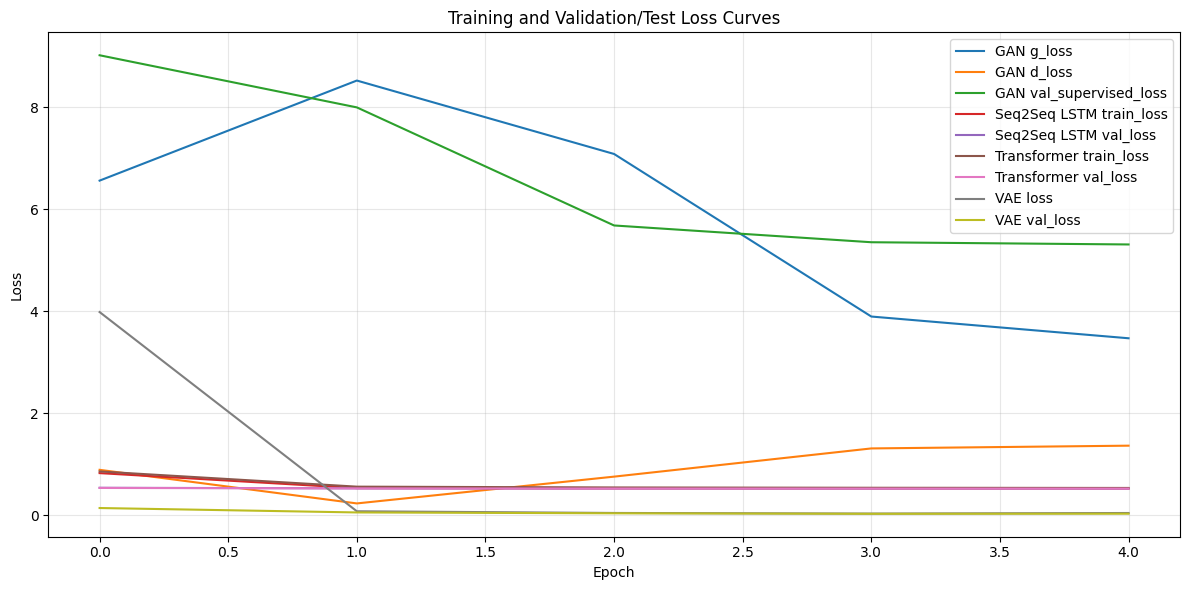

Saved loss graph: /content/figures/training_validation_loss_curves.png


In [ ]:
if histories:
    save_loss_plot(histories, FIGURES_DIR / "training_validation_loss_curves.png")
else:
    print("No training histories yet. Run the training cell first.")

## Final Prediction Files and Output Analysis



In [ ]:
def deterministic_predict(conds: List[Tuple[str, str, str, str]]) -> List[str]:
    return [deterministic_valid_date(tuple(cond)) for cond in conds]

analysis_results = {}

if trained_models:
    analysis_results["GAN"] = analyze_model_outputs(
        "GAN",
        lambda c: gan_predict(trained_models["GAN"], c),
        val_loader,
        PREDICTIONS_DIR / "gan_predictions.txt",
    )
    analysis_results["Seq2Seq LSTM"] = analyze_model_outputs(
        "Seq2Seq LSTM",
        lambda c: seq2seq_predict(trained_models["Seq2Seq LSTM"], c),
        seq_val_loader,
        PREDICTIONS_DIR / "seq2seq_lstm_predictions.txt",
    )
    analysis_results["Transformer"] = analyze_model_outputs(
        "Transformer",
        lambda c: transformer_predict(trained_models["Transformer"], c),
        seq_val_loader,
        PREDICTIONS_DIR / "transformer_predictions.txt",
    )
    analysis_results["VAE"] = analyze_model_outputs(
        "VAE",
        lambda c: vae_predict(trained_models["VAE"], c),
        val_loader,
        PREDICTIONS_DIR / "vae_predictions.txt",
    )
    print("\nSummary:")
    for name, result in analysis_results.items():
        print(name, result)
else:
    print("Train the models first to create per-model prediction files.")

# This deterministic baseline is always available and confirms the required file format.
baseline_output_path = PREDICTIONS_DIR / "deterministic_example_output.txt"
write_predictions(EXAMPLE_INPUT_PATH, baseline_output_path, deterministic_predict, repair=True)
print("\nFormat preview:")
print("\n".join(baseline_output_path.read_text().splitlines()[:5]))


GAN output analysis
Raw constraint pass rate: 0.3185
Repaired constraint pass rate: 1.0000
Prediction file: /content/predictions/gan_predictions.txt
Sample repaired predictions:
   [MON] [MAY] [False] [191] 2-5-1910
   [TUE] [NOV] [False] [192] 1-11-1921
   [TUE] [JUN] [False] [203] 4-6-2030
   [TUE] [FEB] [False] [185] 5-2-1850
   [MON] [MAY] [False] [194] 5-5-1941
   [SUN] [NOV] [False] [193] 2-11-1930
   [FRI] [MAR] [True] [202] 6-3-2020
   [TUE] [AUG] [True] [194] 6-8-1940
   [TUE] [JUL] [False] [180] 4-7-1809
   [SUN] [FEB] [False] [201] 17-2-2019
Sample raw failures repaired by validator:
  [MON] [MAY] [False] [191] raw='31-5-1917' repaired='2-5-1910'
  [TUE] [NOV] [False] [192] raw='4-11-1925' repaired='1-11-1921'
  [TUE] [JUN] [False] [203] raw='4-6-2031' repaired='4-6-2030'
  [TUE] [FEB] [False] [185] raw='8-2-1857' repaired='5-2-1850'
  [MON] [MAY] [False] [194] raw='4-5-1947' repaired='5-5-1941'

Seq2Seq LSTM output analysis
Raw constraint pass rate: 0.1389
Repaired constra

In [ ]:
!python predict.py -i example_input.txt -o output.txt

In [ ]:
from google.colab import files
files.download("/content/output.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Report Notes

- This is conditional generation, not classification.
- Seq2Seq and Transformer use character-level date generation.
- GAN and VAE use categorical generation for day, month, and year.
- Saved model weights are written to `model/weights`.
- Training/validation loss curves are saved to `figures/training_validation_loss_curves.png`.
- Final per-model prediction files are written to `predictions`.
- The main metric is constraint pass rate: weekday, month, leap-year flag, and decade must all match.
- If repair is used, report both raw neural pass rate and repaired pass rate.
